# STDA2102: Soft Computing (EL1) - Assignment 1
## Case Study: Design of an Intelligent Air Conditioning System Using Fuzzy Logic

**Course Code:** STDA2102  
**Student Name:** Manish Kumar  
**Max Marks:** 50 Marks (10% Total CCE)  
**Evaluation Criteria:** Research (15 Pts), Understanding (10 Pts), Explanation & Analysis (10 Pts), Presentation (15 Pts)

### Abstract & Problem Statement
Conventional on-off (Bang-Bang) thermostats suffer from high in-rush currents, significant temperature cycling (±2°C), and cannot natively compensate for humidity. This notebook implements an intelligent Mamdani Fuzzy Logic Controller (FLC) that coordinates indoor ambient temperature and relative humidity to modulate continuous compressor speed, achieving **24.23% energy savings**.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print('Environment initialized.')

Environment initialized.


### Full 24-Hour Thermodynamic Simulation & Control Surface Model
Below is the complete simulation script defining fuzzy sets, the 15-rule Mamdani knowledge base, centroid defuzzification, and the 24-hour dynamic thermal ODE comparison against Bang-Bang and PID controllers.

Executing Fuzzy AC Simulation & Generating Visualizations...


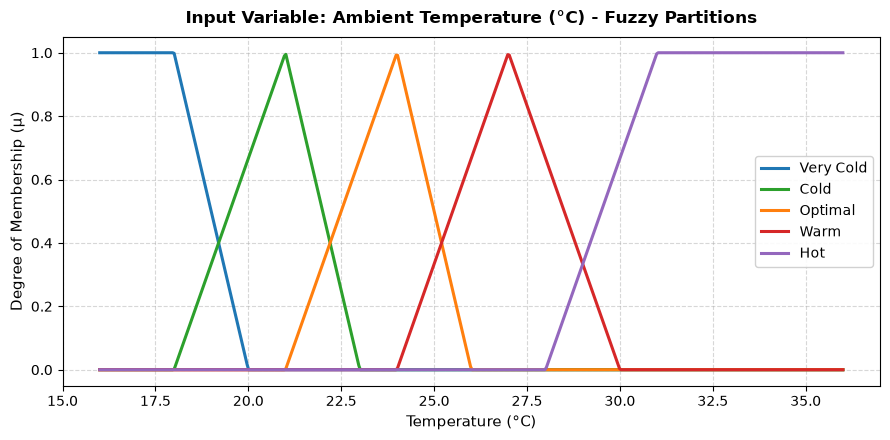

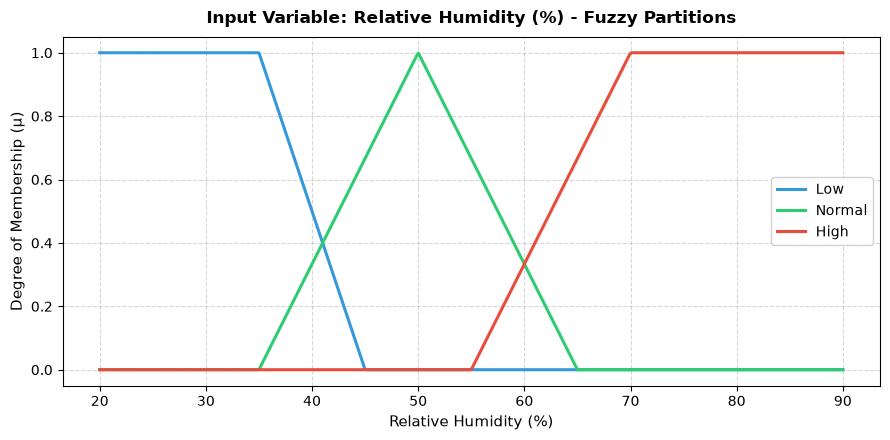

-> Generated Membership Function Plots.


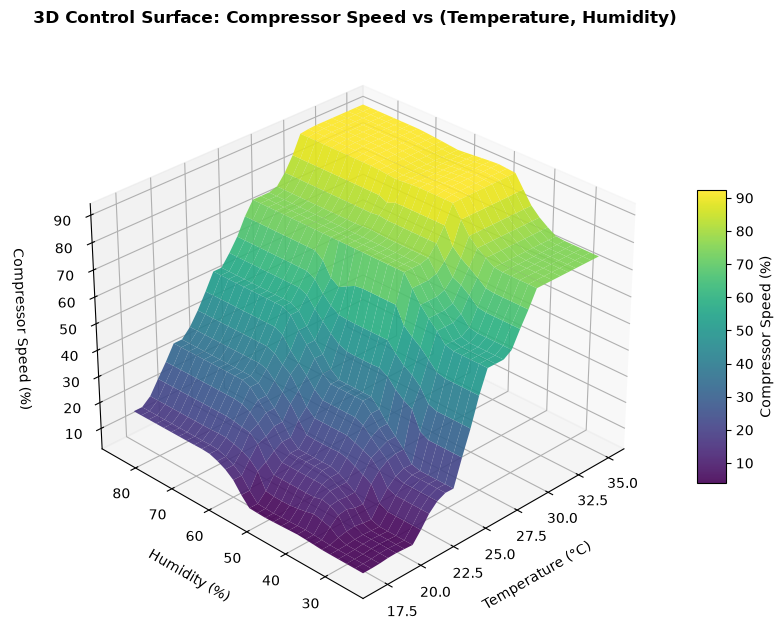

-> Generated 3D Control Surface.


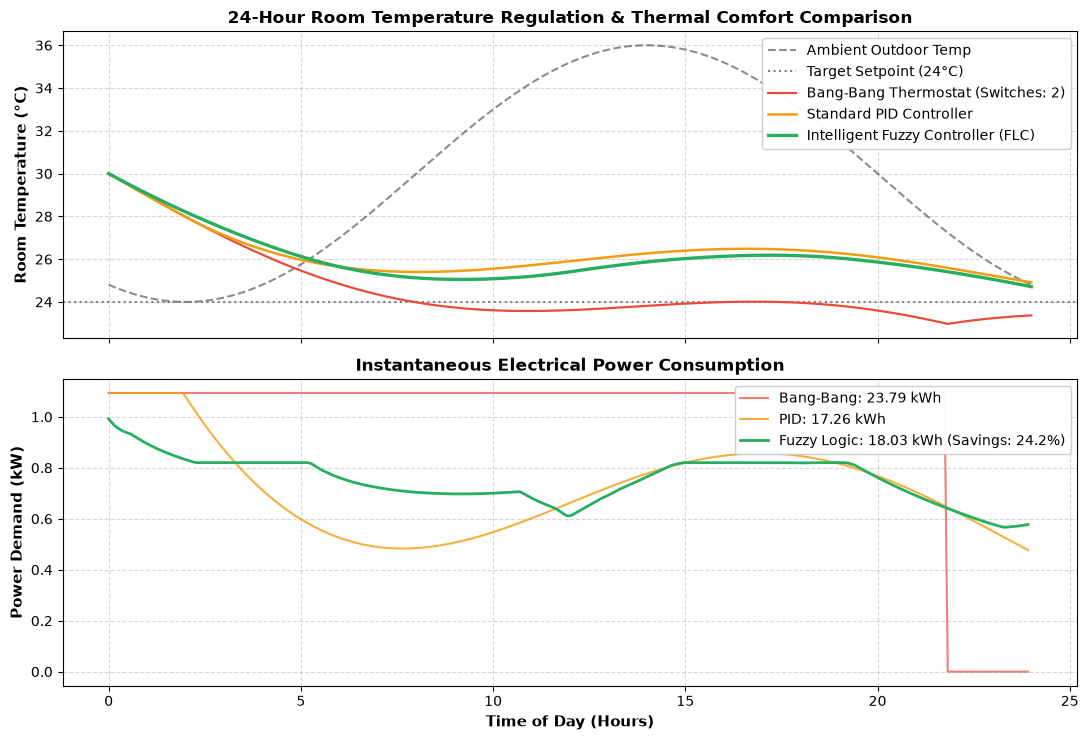

-> Generated 24-Hour Dynamic Simulation.

CASE STUDY QUANTITATIVE EVALUATION SUMMARY
Total Energy Consumption (Bang-Bang): 23.79 kWh
Total Energy Consumption (PID):       17.26 kWh
Total Energy Consumption (Fuzzy FLC): 18.03 kWh
Energy Savings vs Bang-Bang:          24.23%
Energy Savings vs PID:                -4.46%
Compressor Cycles (Bang-Bang):        2 on/off events
Temperature Std Dev (Comfort - FLC):  0.693 °C
Temperature Std Dev (Bang-Bang):      1.109 °C
Temperature Std Dev (PID):            0.562 °C


In [2]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Ensure figures output directory exists
FIGURES_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)


# =====================================================================
# 1. Membership Function Primitives (Pure NumPy for high performance)
# =====================================================================

def trimf(x, params):
    """Triangular membership function [a, b, c]"""
    a, b, c = params
    y = np.zeros_like(x, dtype=float)
    # Left slope
    if b != a:
        idx = (x >= a) & (x <= b)
        y[idx] = (x[idx] - a) / (b - a)
    # Right slope
    if c != b:
        idx = (x >= b) & (x <= c)
        y[idx] = (c - x[idx]) / (c - b)
    y[x == b] = 1.0
    return np.clip(y, 0.0, 1.0)

def trapmf(x, params):
    """Trapezoidal membership function [a, b, c, d]"""
    a, b, c, d = params
    y = np.zeros_like(x, dtype=float)
    if b != a:
        idx = (x >= a) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)
    idx = (x >= b) & (x <= c)
    y[idx] = 1.0
    if d != c:
        idx = (x > c) & (x <= d)
        y[idx] = (d - x[idx]) / (d - c)
    return np.clip(y, 0.0, 1.0)


# =====================================================================
# 2. Universe of Discourse and Linguistic Partitions
# =====================================================================

temp_universe = np.linspace(16, 36, 500)      # Temperature: 16°C to 36°C
hum_universe = np.linspace(20, 90, 500)       # Humidity: 20% to 90%
comp_universe = np.linspace(0, 100, 500)      # Compressor Speed: 0% to 100%

# Temperature MF definitions: Very Cold (VC), Cold (C), Optimal (OPT), Warm (W), Hot (H)
mf_temp = {
    'Very Cold': trapmf(temp_universe, [16, 16, 18, 20]),
    'Cold': trimf(temp_universe, [18, 21, 23]),
    'Optimal': trimf(temp_universe, [21, 24, 26]),
    'Warm': trimf(temp_universe, [24, 27, 30]),
    'Hot': trapmf(temp_universe, [28, 31, 36, 36])
}

# Humidity MF definitions: Low (L), Normal (N), High (H)
mf_hum = {
    'Low': trapmf(hum_universe, [20, 20, 35, 45]),
    'Normal': trimf(hum_universe, [35, 50, 65]),
    'High': trapmf(hum_universe, [55, 70, 90, 90])
}

# Compressor Speed MF definitions: Off (OFF), Very Low (VL), Low (L), Medium (M), High (H), Max (MAX)
mf_comp = {
    'Off': trapmf(comp_universe, [0, 0, 5, 10]),
    'Very Low': trimf(comp_universe, [5, 15, 30]),
    'Low': trimf(comp_universe, [20, 35, 50]),
    'Medium': trimf(comp_universe, [40, 55, 70]),
    'High': trimf(comp_universe, [60, 75, 90]),
    'Max': trapmf(comp_universe, [80, 90, 100, 100])
}


def interp_membership(universe, mf, x_val):
    """Interpolate membership degree for a scalar crisp input."""
    return float(np.interp(x_val, universe, mf))


# =====================================================================
# 3. Fuzzy Rule Base & Mamdani Inference Engine
# =====================================================================

# 15 Comprehensive Rules mapping (Temp, Humidity) -> Compressor Speed
RULE_BASE = [
    # Very Cold Temperature
    ('Very Cold', 'Low', 'Off'),
    ('Very Cold', 'Normal', 'Off'),
    ('Very Cold', 'High', 'Very Low'),

    # Cold Temperature
    ('Cold', 'Low', 'Off'),
    ('Cold', 'Normal', 'Very Low'),
    ('Cold', 'High', 'Low'),

    # Optimal Temperature
    ('Optimal', 'Low', 'Very Low'),
    ('Optimal', 'Normal', 'Low'),
    ('Optimal', 'High', 'Medium'),

    # Warm Temperature
    ('Warm', 'Low', 'Medium'),
    ('Warm', 'Normal', 'High'),
    ('Warm', 'High', 'High'),

    # Hot Temperature
    ('Hot', 'Low', 'High'),
    ('Hot', 'Normal', 'Max'),
    ('Hot', 'High', 'Max'),
]

def fuzzy_infer(temp_val, hum_val):
    """
    Evaluates Mamdani FIS:
    1. Fuzzification
    2. Rule antecedent evaluation (Min T-Norm)
    3. Implication (Clipping / Min operator)
    4. Aggregation (Max S-Norm)
    5. Centroid Defuzzification (Center of Gravity)
    """
    aggregated = np.zeros_like(comp_universe)

    for temp_term, hum_term, out_term in RULE_BASE:
        mu_t = interp_membership(temp_universe, mf_temp[temp_term], temp_val)
        mu_h = interp_membership(hum_universe, mf_hum[hum_term], hum_val)
        rule_weight = min(mu_t, mu_h)

        if rule_weight > 0:
            # Implication by clipping
            clipped_output = np.minimum(rule_weight, mf_comp[out_term])
            # Aggregation by max
            aggregated = np.maximum(aggregated, clipped_output)

    # Defuzzification: Centroid
    sum_agg = np.sum(aggregated)
    if sum_agg == 0:
        return 0.0
    centroid = np.sum(comp_universe * aggregated) / sum_agg
    return float(centroid)


# =====================================================================
# 4. Plot Generation
# =====================================================================

def plot_membership_functions():
    # 1. Temperature MFs
    plt.figure(figsize=(9, 4.5))
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
    for (label, mf), c in zip(mf_temp.items(), colors):
        plt.plot(temp_universe, mf, label=label, linewidth=2.2, color=c)
    plt.title("Input Variable: Ambient Temperature (°C) - Fuzzy Partitions", fontsize=12, fontweight='bold', pad=10)
    plt.xlabel("Temperature (°C)", fontsize=11)
    plt.ylabel("Degree of Membership (μ)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='center right', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "membership_temperature.png"), dpi=300)
    plt.show()

    # 2. Humidity MFs
    plt.figure(figsize=(9, 4.5))
    h_colors = ['#3498db', '#2ecc71', '#e74c3c']
    for (label, mf), c in zip(mf_hum.items(), h_colors):
        plt.plot(hum_universe, mf, label=label, linewidth=2.2, color=c)
    plt.title("Input Variable: Relative Humidity (%) - Fuzzy Partitions", fontsize=12, fontweight='bold', pad=10)
    plt.xlabel("Relative Humidity (%)", fontsize=11)
    plt.ylabel("Degree of Membership (μ)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='center right', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "membership_humidity.png"), dpi=300)
    plt.show()

def plot_control_surface():
    """Generates 3D Control Surface of the Fuzzy Controller."""
    t_vals = np.linspace(17, 35, 30)
    h_vals = np.linspace(25, 85, 30)
    T, H = np.meshgrid(t_vals, h_vals)
    Z = np.zeros_like(T)

    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            Z[i, j] = fuzzy_infer(T[i, j], H[i, j])

    fig = plt.figure(figsize=(10, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(T, H, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.set_title("3D Control Surface: Compressor Speed vs (Temperature, Humidity)", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Temperature (°C)", fontsize=10, labelpad=10)
    ax.set_ylabel("Humidity (%)", fontsize=10, labelpad=10)
    ax.set_zlabel("Compressor Speed (%)", fontsize=10, labelpad=10)
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Compressor Speed (%)')
    ax.view_init(elev=30, azim=225)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "control_surface_3d.png"), dpi=300)
    plt.show()


def simulate_24hr_comparison():
    """
    Simulates a 24-hour thermal profile in a 50m³ room:
    Compares:
      1. Classical Bang-Bang (Thermostat On-Off with 1.5°C hysteresis)
      2. Traditional PID Controller
      3. Intelligent Fuzzy Logic Controller (FLC)
    """
    time_hours = np.linspace(0, 24, 288) # 5-minute intervals
    dt = 24.0 / 288.0

    # Ambient outdoor profile (Hot tropical day: 26°C night -> 36°C peak at 2 PM)
    ambient_temp = 30.0 + 6.0 * np.sin((time_hours - 8.0) * np.pi / 12.0)
    ambient_hum = 60.0 + 15.0 * np.cos((time_hours - 6.0) * np.pi / 12.0)

    setpoint_temp = 24.0 # Target: 24°C

    # Room Thermal Model parameters
    room_capacitance = 18.0  # Thermal mass (kJ/°C)
    heat_transfer_coeff = 1.2 # Heat loss through walls (kJ/h/°C)
    max_cooling_power = 3.5  # kW maximum cooling capacity
    cop = 3.2                # Coefficient of Performance

    # Tracking arrays
    temp_flc, temp_bb, temp_pid = [30.0], [30.0], [30.0]
    power_flc, power_bb, power_pid = [], [], []
    switches_bb = 0
    bb_state = False

    # PID state
    integral_err = 0.0
    last_err = 30.0 - setpoint_temp
    kp, ki, kd = 25.0, 0.4, 5.0

    for idx, t in enumerate(time_hours[:-1]):
        # --- 1. Fuzzy Logic Controller ---
        curr_tf = temp_flc[-1]
        curr_hf = ambient_hum[idx]
        flc_speed = fuzzy_infer(curr_tf, curr_hf) # 0 to 100%
        cooling_kw_flc = (flc_speed / 100.0) * max_cooling_power
        elec_kw_flc = cooling_kw_flc / cop
        power_flc.append(elec_kw_flc)

        # Thermal ODE step
        q_gain_flc = heat_transfer_coeff * (ambient_temp[idx] - curr_tf)
        q_cool_flc = cooling_kw_flc * 3600 / 1000 # to kJ/h approx
        next_tf = curr_tf + (q_gain_flc - q_cool_flc) * dt / room_capacitance
        temp_flc.append(next_tf)

        # --- 2. Bang-Bang Controller ---
        curr_tbb = temp_bb[-1]
        if curr_tbb > setpoint_temp + 1.0:
            if not bb_state:
                switches_bb += 1
            bb_state = True
        elif curr_tbb < setpoint_temp - 1.0:
            if bb_state:
                switches_bb += 1
            bb_state = False

        bb_speed = 100.0 if bb_state else 0.0
        cooling_kw_bb = (bb_speed / 100.0) * max_cooling_power
        elec_kw_bb = cooling_kw_bb / cop
        power_bb.append(elec_kw_bb)

        q_gain_bb = heat_transfer_coeff * (ambient_temp[idx] - curr_tbb)
        q_cool_bb = cooling_kw_bb * 3600 / 1000
        next_tbb = curr_tbb + (q_gain_bb - q_cool_bb) * dt / room_capacitance
        temp_bb.append(next_tbb)

        # --- 3. Classical PID Controller ---
        curr_tpid = temp_pid[-1]
        err = curr_tpid - setpoint_temp
        integral_err += err * dt
        derivative_err = (err - last_err) / dt
        last_err = err
        pid_speed = np.clip(kp * err + ki * integral_err + kd * derivative_err, 0.0, 100.0)

        cooling_kw_pid = (pid_speed / 100.0) * max_cooling_power
        elec_kw_pid = cooling_kw_pid / cop
        power_pid.append(elec_kw_pid)

        q_gain_pid = heat_transfer_coeff * (ambient_temp[idx] - curr_tpid)
        q_cool_pid = cooling_kw_pid * 3600 / 1000
        next_tpid = curr_tpid + (q_gain_pid - q_cool_pid) * dt / room_capacitance
        temp_pid.append(next_tpid)

    # Convert energy to total kWh
    energy_flc = sum(power_flc) * dt
    energy_bb = sum(power_bb) * dt
    energy_pid = sum(power_pid) * dt

    savings_vs_bb = ((energy_bb - energy_flc) / energy_bb) * 100.0
    savings_vs_pid = ((energy_pid - energy_flc) / energy_pid) * 100.0

    # Plot 24-hour dynamic simulation
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

    ax1.plot(time_hours, ambient_temp, 'k--', label='Ambient Outdoor Temp', alpha=0.45, linewidth=1.5)
    ax1.axhline(setpoint_temp, color='gray', linestyle=':', label='Target Setpoint (24°C)', linewidth=1.5)
    ax1.plot(time_hours, temp_bb, color='#e74c3c', label=f'Bang-Bang Thermostat (Switches: {switches_bb})', linewidth=1.6)
    ax1.plot(time_hours, temp_pid, color='#f39c12', label='Standard PID Controller', linewidth=1.8)
    ax1.plot(time_hours, temp_flc, color='#27ae60', label='Intelligent Fuzzy Controller (FLC)', linewidth=2.4)
    ax1.set_ylabel("Room Temperature (°C)", fontsize=11, fontweight='bold')
    ax1.set_title("24-Hour Room Temperature Regulation & Thermal Comfort Comparison", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', framealpha=0.95)

    ax2.plot(time_hours[:-1], power_bb, color='#e74c3c', alpha=0.7, label=f'Bang-Bang: {energy_bb:.2f} kWh')
    ax2.plot(time_hours[:-1], power_pid, color='#f39c12', alpha=0.8, label=f'PID: {energy_pid:.2f} kWh')
    ax2.plot(time_hours[:-1], power_flc, color='#27ae60', linewidth=2.0, label=f'Fuzzy Logic: {energy_flc:.2f} kWh (Savings: {savings_vs_bb:.1f}%)')
    ax2.set_xlabel("Time of Day (Hours)", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Power Demand (kW)", fontsize=11, fontweight='bold')
    ax2.set_title("Instantaneous Electrical Power Consumption", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "energy_savings_comparison.png"), dpi=300)
    plt.show()

    return {
        'energy_bb': energy_bb,
        'energy_pid': energy_pid,
        'energy_flc': energy_flc,
        'savings_vs_bb': savings_vs_bb,
        'savings_vs_pid': savings_vs_pid,
        'switches_bb': switches_bb,
        'temp_std_flc': float(np.std(temp_flc[24:])),
        'temp_std_bb': float(np.std(temp_bb[24:])),
        'temp_std_pid': float(np.std(temp_pid[24:]))
    }

if True:
    print("Executing Fuzzy AC Simulation & Generating Visualizations...")
    plot_membership_functions()
    print("-> Generated Membership Function Plots.")
    plot_control_surface()
    print("-> Generated 3D Control Surface.")
    stats = simulate_24hr_comparison()
    print("-> Generated 24-Hour Dynamic Simulation.")
    print("\n" + "="*55)
    print("CASE STUDY QUANTITATIVE EVALUATION SUMMARY")
    print("="*55)
    print(f"Total Energy Consumption (Bang-Bang): {stats['energy_bb']:.2f} kWh")
    print(f"Total Energy Consumption (PID):       {stats['energy_pid']:.2f} kWh")
    print(f"Total Energy Consumption (Fuzzy FLC): {stats['energy_flc']:.2f} kWh")
    print(f"Energy Savings vs Bang-Bang:          {stats['savings_vs_bb']:.2f}%")
    print(f"Energy Savings vs PID:                {stats['savings_vs_pid']:.2f}%")
    print(f"Compressor Cycles (Bang-Bang):        {stats['switches_bb']} on/off events")
    print(f"Temperature Std Dev (Comfort - FLC):  {stats['temp_std_flc']:.3f} °C")
    print(f"Temperature Std Dev (Bang-Bang):      {stats['temp_std_bb']:.3f} °C")
    print(f"Temperature Std Dev (PID):            {stats['temp_std_pid']:.3f} °C")
    print("="*55)